For this experiment, we will try do test/training prediction on El-Centro Earthquake data-driven ODE
$$\ddot{U} + \frac{.08\pi}{5} \dot{U} + \left(\frac{2\pi}{5}\right)^2 U = -9.81 \cdot a(t)$$
The first part here will be solving the ODE using the Signature Kernel Method.
\\
\\
Here, we will only use PyTorch


In [1]:
import pandas as pd
import signatory
import torch
import math
import matplotlib.pyplot as plt

# Problem Setup
xi = .02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a = -9.81
F_t = pd.read_csv("EQDATA.csv")
u_t = pd.read_csv("U_elcentro.csv")
t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a * torch.tensor(F_t["F"].values, dtype=torch.float64)
solution = pd.read_csv("U_elcentro.csv")
t_true = torch.tensor(solution['t_u'].values, dtype=torch.float64)
u_true = torch.tensor(solution['U'].values, dtype=torch.float64)


def trapezoidal_cols(M, dt):
    """Cumulative trapezoidal integral along dim=0, works for 1D or 2D tensors."""
    trap = (M[:-1] + M[1:]) / 2 * dt
    out = torch.zeros_like(M)
    out[1:] = torch.cumsum(trap, dim=0)
    return out

dt = t_vals[1] - t_vals[0]
F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)

t_start = 0
t_end = 31.18
num_partitions = 1560
total_points = len(F_t)
partition_size = total_points // num_partitions
window_size = 400

# Build all paths in one shot using tensor unfold.
data = torch.stack([
    torch.tensor(F_t.iloc[:, 0].values, dtype=torch.float64),
    torch.tensor(F_t.iloc[:, 1].values, dtype=torch.float64)
], dim=1)                                                      # (total_points, 2)
pad = data[0].unsqueeze(0).expand(window_size - 1, -1)        # (window_size-1, 2)
padded_tensor = torch.cat([pad, data], dim=0)                  # (total_points + window_size - 1, 2)

# unfold(dim, size, step) -> (total_points, 2, window_size), permute -> (total_points, window_size, 2)
all_paths = padded_tensor.unfold(0, window_size, 1).permute(0, 2, 1)

# Compute all signatures in a single batched call
signature_level = 12
S = signatory.signature(
    all_paths,
    depth=signature_level,
    basepoint=True,
    scalar_term=True
).detach()

print("len(S) =", len(S))

# Normalise using numpy-compatible median and quantile
median = torch.quantile(S,0.5, dim =0)
q75 = torch.quantile(S, 0.75,dim=0)
q25 = torch.quantile(S, 0.25,dim=0)
iqr = q75 - q25 + 1e-8
S = (S - median) / iqr

print(len(S))

N = len(S)
dt = t_vals[1] - t_vals[0]

# K, K1, K2 all fully vectorised — no Python loops
K  = S @ S.T
K1 = trapezoidal_cols(K, dt)
K2 = trapezoidal_cols(K1, dt)

Psi = m * K + c * K1 + k * K2
print("Rank(Psi):", torch.linalg.matrix_rank(Psi).item())

# Solve least squares — driver='gelsd' with float64 machine epsilon matches
rcond = torch.finfo(torch.float64).eps
A = torch.linalg.lstsq(Psi, F_star, rcond=rcond, driver='gelsd').solution


len(S) = 1560
1560
Rank(Psi): 871


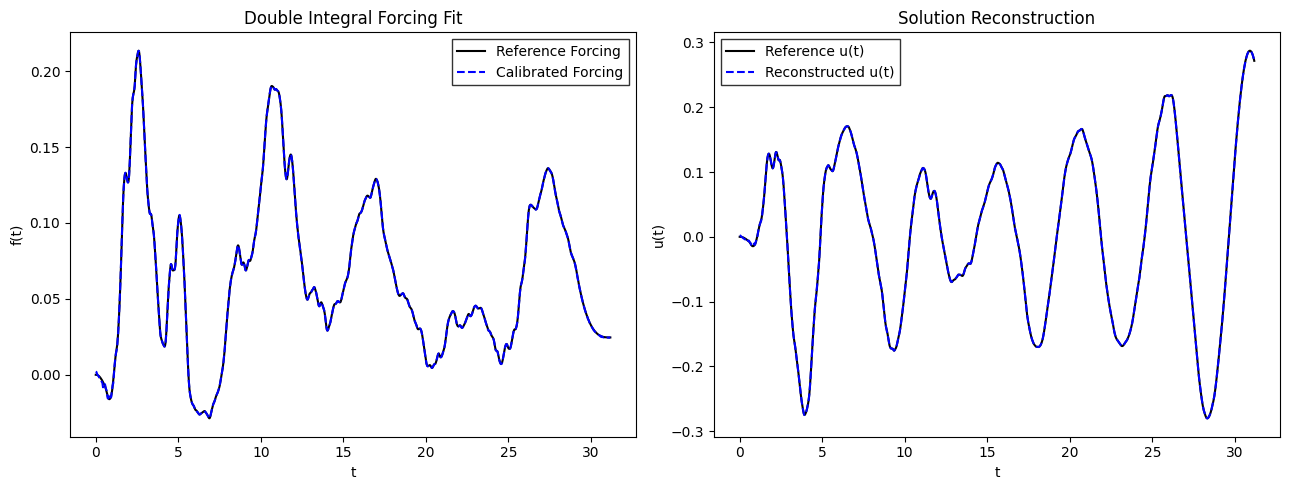

In [11]:
# =========================
# --- Plot 1: Double Integral Forcing Fit ---
# =========================
F_hat = Psi @ A
time_plot = torch.linspace(0, 31.18, len(F_hat))

K_A = K @ A
t_grid = torch.linspace(t_start, t_end, len(K_A))

if len(K_A) != len(u_true):
    idx = torch.searchsorted(t_true.contiguous(), t_grid.contiguous())
    idx = idx.clamp(1, len(t_true) - 1)
    t0 = t_true[idx - 1]; t1 = t_true[idx]
    u0 = u_true[idx - 1]; u1 = u_true[idx]
    weight = (t_grid - t0) / (t1 - t0)
    u_true_interp = u0 + weight * (u1 - u0)
else:
    u_true_interp = u_true

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Forcing
axes[0].plot(time_plot.tolist(), F_star.tolist(),
             color="black", linewidth=1.5, label="Reference Forcing")
axes[0].plot(time_plot.tolist(), F_hat.tolist(),
             color="blue", linestyle="--", linewidth=1.5, label="Calibrated Forcing")
axes[0].set_title("Double Integral Forcing Fit")
axes[0].set_xlabel("t")
axes[0].set_ylabel("f(t)")
axes[0].legend(frameon=True, fancybox=False, edgecolor="black")

# Right: Solution
axes[1].plot(t_grid.tolist(), u_true_interp.tolist(),
             color="black", linewidth=1.5, label="Reference u(t)")
axes[1].plot(t_grid.tolist(), K_A.tolist(),
             color="blue", linestyle="--", linewidth=1.5, label="Reconstructed u(t)")
axes[1].set_title("Solution Reconstruction")
axes[1].set_xlabel("t")
axes[1].set_ylabel("u(t)")
axes[1].legend(frameon=True, fancybox=False, edgecolor="black")

fig.tight_layout()
plt.show()

In [12]:
# =========================
# MSE + Relative MSE for Forcing and Solution
# =========================

import numpy as np

# Model predictions
F_pred = Psi @ A          # predicted twice-integrated forcing F*
u_pred = K @ A           # predicted displacement solution u(t)

# Interpolate true solution onto t_vals grid
u_true_interp = torch.tensor(
    np.interp(
        t_vals.detach().cpu().numpy(),
        t_true.detach().cpu().numpy(),
        u_true.detach().cpu().numpy()
    ),
    dtype=torch.float64
)

def mse(pred, true):
    return torch.mean((pred - true) ** 2).item()

def rel_mse(pred, true):
    return torch.mean((pred - true) ** 2).item() / torch.mean(true ** 2).item()

# Forcing errors
abs_mse_F = mse(F_pred, F_star)
rel_mse_F = rel_mse(F_pred, F_star)

# Solution errors
abs_mse_u = mse(u_pred, u_true_interp)
rel_mse_u = rel_mse(u_pred, u_true_interp)

print("\n==============================")
print("Model Error Summary")
print("==============================")
print(f"{'Quantity':20s} {'Absolute MSE':>18s} {'Relative MSE':>18s} {'Relative MSE (%)':>20s}")
print("-" * 80)
print(f"{'Forcing F*':20s} {abs_mse_F:>18.6e} {rel_mse_F:>18.6e} {100 * rel_mse_F:>19.4f}%")
print(f"{'Solution u(t)':20s} {abs_mse_u:>18.6e} {rel_mse_u:>18.6e} {100 * rel_mse_u:>19.4f}%")


Model Error Summary
Quantity                   Absolute MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------
Forcing F*                 8.223500e-08       1.186030e-05              0.0012%
Solution u(t)              1.022532e-07       5.967132e-06              0.0006%


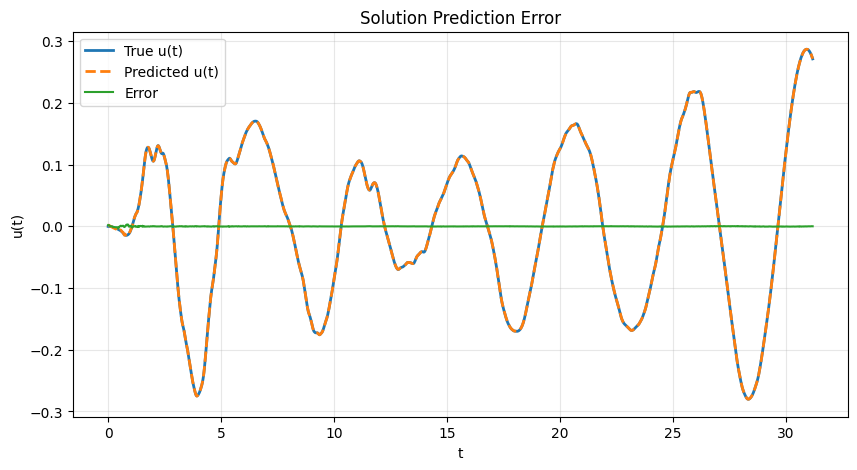

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(t_vals, u_true_interp, label="True u(t)", linewidth=2)
plt.plot(t_vals, u_pred, "--", label="Predicted u(t)", linewidth=2)
plt.plot(t_vals, u_pred - u_true_interp, label="Error", linewidth=1.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Solution Prediction Error")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.show()

In [3]:
def signature_of_path(path, depth=12):
    if not isinstance(path, torch.Tensor):
        path = torch.tensor(path, dtype=torch.float64)
    path_tensor = path.unsqueeze(0)
    sig = signatory.signature(
        path_tensor,
        depth=depth,
        basepoint=True,
        scalar_term=True,
    ).squeeze(0)
    return sig.detach()

def robust_fit(S, eps=1e-5):
    N = S.shape[0]
    S_sorted = torch.sort(S, dim=0).values
    if N % 2 == 1:
        med = S_sorted[N // 2]
    else:
        med = (S_sorted[N // 2 - 1] + S_sorted[N // 2]) / 2.0
    q75 = torch.quantile(S.double(), 0.75, dim=0)
    q25 = torch.quantile(S.double(), 0.25, dim=0)
    iqr = q75 - q25
    return med, iqr + eps

def robust_apply(x, med, iqr):
    return (x - med) / iqr


xi = 0.02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a_g = -9.81

signature_level = 8
n0 = 200

# =========================
# Load data
# =========================
F_t = pd.read_csv("EQDATA.csv")
solution = pd.read_csv("U_elcentro.csv")

t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a_g * torch.tensor(F_t["F"].values, dtype=torch.float64)

t_true = torch.tensor(solution["t_u"].values, dtype=torch.float64)
u_true = torch.tensor(solution["U"].values, dtype=torch.float64)

dt = float((t_vals[1] - t_vals[0]).item())
N = len(t_vals)

F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)

if len(u_true) != len(t_vals) or not torch.allclose(t_true, t_vals):
    idx_interp = torch.searchsorted(t_true.contiguous(), t_vals.contiguous())
    idx_interp = idx_interp.clamp(1, len(t_true) - 1)
    t0 = t_true[idx_interp - 1]
    t1 = t_true[idx_interp]
    u0 = u_true[idx_interp - 1]
    u1 = u_true[idx_interp]
    weight = (t_vals - t0) / (t1 - t0)
    u_true_interp = u0 + weight * (u1 - u0)
else:
    u_true_interp = u_true


# =========================
# Path construction — branched (with t-lift) and non-branched
# =========================
paths_branched = []
paths_nonbranched = []

for i in range(num_partitions):
    end_index = (i + 1) * partition_size
    if i == num_partitions - 1:
        end_index = total_points

    path_b = []
    path_nb = []
    for j in range(end_index):
        t_val = F_t.iloc[j, 0]
        f_val = F_t.iloc[j, 1]
        ta2 = t_val ** 0.3
        path_b.append([t_val, f_val, ta2])
        path_nb.append([t_val, f_val])

    paths_branched.append(path_b)
    paths_nonbranched.append(path_nb)


# =========================
# Baseline training — branched
# =========================
S0_raw = []
for i in range(n0 + 1):
    S0_raw.append(signature_of_path(paths_branched[i], depth=signature_level))
S0_raw = torch.stack(S0_raw)

med_b, iqr_b = robust_fit(S0_raw)
S0 = robust_apply(S0_raw, med_b, iqr_b)

K0 = S0 @ S0.T
K1_0 = trapezoidal_cols(K0, dt)
K2_0 = trapezoidal_cols(K1_0, dt)

Psi0 = m * K0 + c * K1_0 + k * K2_0
rcond = torch.finfo(torch.float64).eps
alpha0 = torch.linalg.lstsq(Psi0, F_star[:n0+1], rcond=rcond, driver='gelsd').solution

# Compute training predictions for branched
F_pred_train_b = (Psi0 @ alpha0)
K_train_b = K0 @ alpha0
u_pred_train_b = K_train_b

state_branched = {
    "m": m, "c": c, "k": k,
    "dt": dt, "n0": n0, "N": N,
    "paths": paths_branched,
    "signature_level": signature_level,
    "med": med_b, "iqr": iqr_b,
    "F_star": F_star,
    "t_vals": t_vals,
    "u_true_interp": u_true_interp,
    "alpha0": alpha0,
    "S_hist": S0.clone(),
    "K_prev": K0[n0, :].clone(),
    "I1": K1_0[n0, :].clone(),
    "I2": K2_0[n0, :].clone(),
}

# =========================
# Baseline training — non-branched
# =========================
S0_raw_nb = []
for i in range(n0 + 1):
    S0_raw_nb.append(signature_of_path(paths_nonbranched[i], depth=signature_level))
S0_raw_nb = torch.stack(S0_raw_nb)

med_nb, iqr_nb = robust_fit(S0_raw_nb)
S0_nb = robust_apply(S0_raw_nb, med_nb, iqr_nb)

K0_nb = S0_nb @ S0_nb.T
K1_0_nb = trapezoidal_cols(K0_nb, dt)
K2_0_nb = trapezoidal_cols(K1_0_nb, dt)

Psi0_nb = m * K0_nb + c * K1_0_nb + k * K2_0_nb
alpha0_nb = torch.linalg.lstsq(Psi0_nb, F_star[:n0+1], rcond=rcond, driver='gelsd').solution

F_pred_train_nb = (Psi0_nb @ alpha0_nb)
K_train_nb = K0_nb @ alpha0_nb
u_pred_train_nb = K_train_nb

state_nonbranched = {
    "m": m, "c": c, "k": k,
    "dt": dt, "n0": n0, "N": N,
    "paths": paths_nonbranched,
    "signature_level": signature_level,
    "med": med_nb, "iqr": iqr_nb,
    "F_star": F_star,
    "t_vals": t_vals,
    "u_true_interp": u_true_interp,
    "alpha0": alpha0_nb,
    "S_hist": S0_nb.clone(),
    "K_prev": K0_nb[n0, :].clone(),
    "I1": K1_0_nb[n0, :].clone(),
    "I2": K2_0_nb[n0, :].clone(),
}

print("TRAIN DONE.")


def rolling_online_predict(state, retrain_every=5, max_steps=None):
    m, c, k = state["m"], state["c"], state["k"]
    dt = state["dt"]
    n0 = state["n0"]
    N = state["N"]
    paths = state["paths"]
    depth = state["signature_level"]
    med, iqr = state["med"], state["iqr"]
    F_star = state["F_star"]
    u_true = state["u_true_interp"]

    if max_steps is None:
        end_idx = N - 1
    else:
        end_idx = min(N - 1, n0 + max_steps)

    S_hist = state["S_hist"].clone()
    alphas = torch.zeros(end_idx + 1, dtype=torch.float64)
    alphas[:n0+1] = state["alpha0"]

    K_prev = state["K_prev"].clone()
    I1 = state["I1"].clone()
    I2 = state["I2"].clone()

    F_pred = torch.zeros(end_idx + 1, dtype=torch.float64)
    u_pred = torch.zeros(end_idx + 1, dtype=torch.float64)

    retrain_indices = []
    eps = 1e-3

    for i in range(n0 + 1, end_idx + 1):
        s_raw = signature_of_path(paths[i], depth=depth)
        s_new = robust_apply(s_raw, med, iqr)

        k_row_old = S_hist @ s_new
        k_ii = float(torch.dot(s_new, s_new).item())

        I1_new = I1 + 0.5 * (K_prev + k_row_old) * dt
        I2_new = I2 + 0.5 * (I1 + I1_new) * dt
        I1, I2 = I1_new, I2_new
        K_prev = k_row_old

        col_i = torch.cat([k_row_old, torch.tensor([k_ii], dtype=torch.float64)])
        inner_i = trapezoidal_cols(col_i, dt)
        outer_i = trapezoidal_cols(inner_i, dt)
        I1_i = float(inner_i[-1].item())
        I2_i = float(outer_i[-1].item())

        I1 = torch.cat([I1, torch.tensor([I1_i], dtype=torch.float64)])
        I2 = torch.cat([I2, torch.tensor([I2_i], dtype=torch.float64)])
        K_prev = torch.cat([K_prev, torch.tensor([k_ii], dtype=torch.float64)])

        psi_row_old = m * k_row_old + c * I1[:i] + k * I2[:i]
        psi_diag = m * k_ii + c * I1[i].item() + k * I2[i].item()

        residual = F_star[i] - torch.dot(psi_row_old, alphas[:i])
        alphas[i] = residual / (psi_diag + eps)

        F_pred[i] = torch.dot(psi_row_old, alphas[:i]) + psi_diag * alphas[i]
        u_pred[i] = torch.dot(k_row_old, alphas[:i]) + k_ii * alphas[i]

        S_hist = torch.vstack([S_hist, s_new.unsqueeze(0)])

        if (i - n0) % retrain_every == 0:
            print(f"[Retrain] at index {i}")
            retrain_indices.append(i)

            K = S_hist @ S_hist.T
            K1 = trapezoidal_cols(K, dt)
            K2 = trapezoidal_cols(K1, dt)
            Psi = m * K + c * K1 + k * K2
            Psi_block = Psi[:i+1, :i+1]
            F_block = F_star[:i+1]

            scale = torch.mean(torch.diag(Psi_block))
            lam = 1e-13 * scale
            I_mat = torch.eye(i+1, dtype=torch.float64)
            alphas[:i+1] = torch.linalg.solve(Psi_block + lam * I_mat, F_block)

    return {
        "F_pred": F_pred,
        "u_pred": u_pred,
        "retrain_indices": retrain_indices,
        "end_idx": end_idx,
    }


# =========================
# Run both
# =========================
print("Running branched (t-lift)...")
res_b = rolling_online_predict(state_branched, retrain_every=5)

print("Running non-branched...")
res_nb = rolling_online_predict(state_nonbranched, retrain_every=5)


TRAIN DONE.
Running branched (t-lift)...
[Retrain] at index 205
[Retrain] at index 210
[Retrain] at index 215
[Retrain] at index 220
[Retrain] at index 225
[Retrain] at index 230
[Retrain] at index 235
[Retrain] at index 240
[Retrain] at index 245
[Retrain] at index 250
[Retrain] at index 255
[Retrain] at index 260
[Retrain] at index 265
[Retrain] at index 270
[Retrain] at index 275
[Retrain] at index 280
[Retrain] at index 285
[Retrain] at index 290
[Retrain] at index 295
[Retrain] at index 300
[Retrain] at index 305
[Retrain] at index 310
[Retrain] at index 315
[Retrain] at index 320
[Retrain] at index 325
[Retrain] at index 330
[Retrain] at index 335
[Retrain] at index 340
[Retrain] at index 345
[Retrain] at index 350
[Retrain] at index 355
[Retrain] at index 360
[Retrain] at index 365
[Retrain] at index 370
[Retrain] at index 375
[Retrain] at index 380
[Retrain] at index 385
[Retrain] at index 390
[Retrain] at index 395
[Retrain] at index 400
[Retrain] at index 405
[Retrain] at ind

KeyboardInterrupt: 

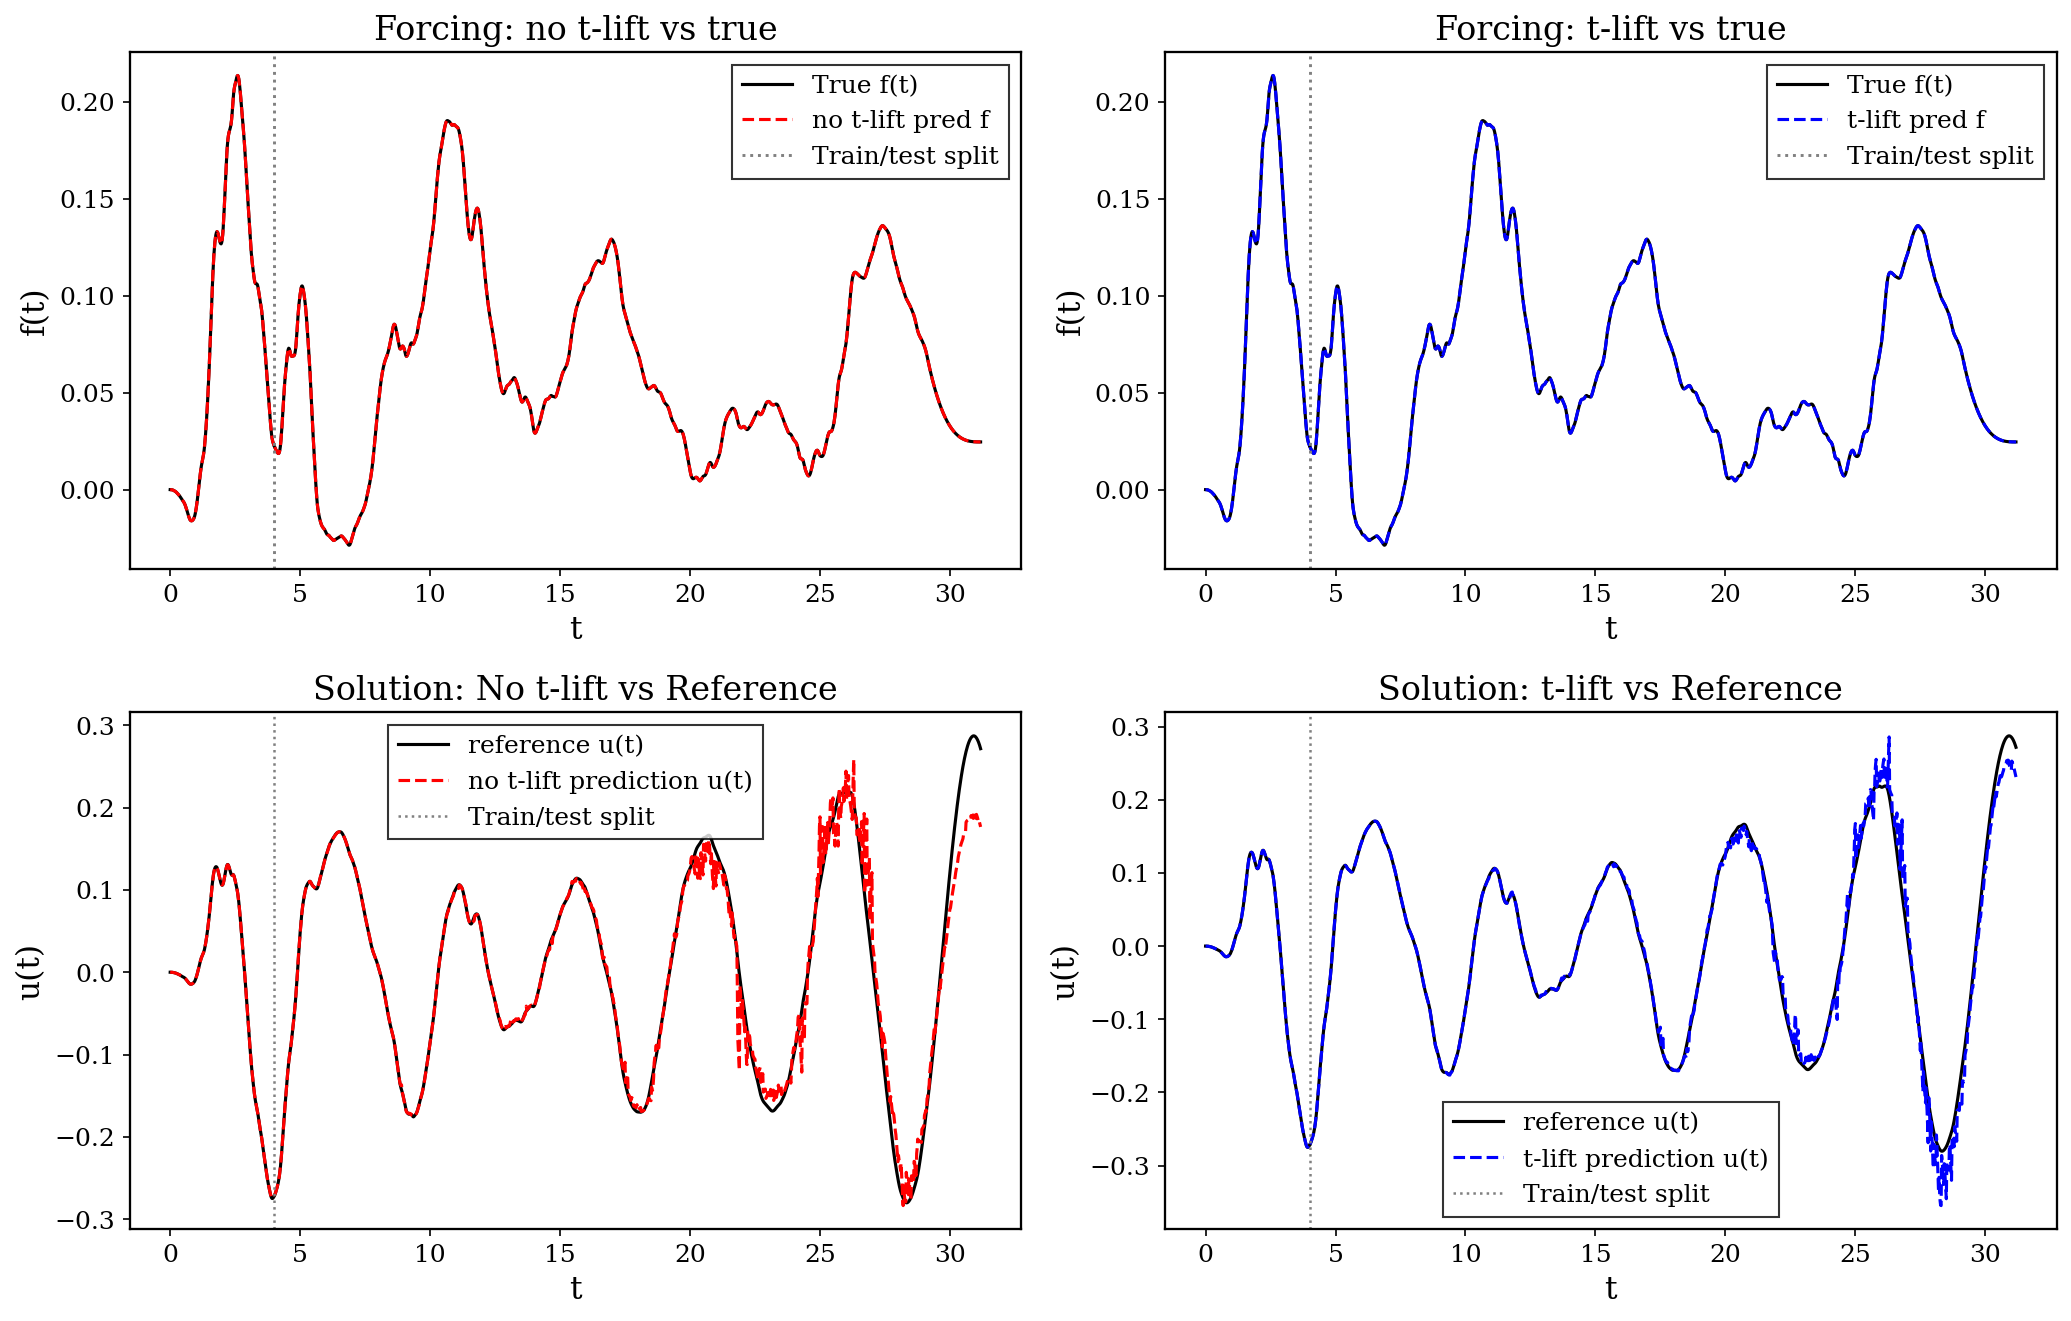

In [ ]:
# =========================
# Plot — 2x2, full path (train + test), dotted vertical split
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.1,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Full index ranges
idx_train = torch.arange(0, n0 + 1)
idx_test_b  = torch.arange(n0 + 1, res_b["end_idx"]  + 1)
idx_test_nb = torch.arange(n0 + 1, res_nb["end_idx"] + 1)

t_train    = t_vals[idx_train]
t_test_b   = t_vals[idx_test_b]
t_test_nb  = t_vals[idx_test_nb]
t_split    = float(t_vals[n0].item())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Top-left: Forcing, non-branched ---
ax = axes[0, 0]
ax.plot(t_train.tolist(), F_star[idx_train].tolist(),
        color="black", linewidth=1.5, label="True f(t)")
ax.plot(t_train.tolist(), F_pred_train_nb.tolist(),
        color="red", linestyle="--", linewidth=1.5)
ax.plot(t_test_nb.tolist(), F_star[idx_test_nb].tolist(),
        color="black", linewidth=1.5)
ax.plot(t_test_nb.tolist(), res_nb["F_pred"][idx_test_nb].tolist(),
        color="red", linestyle="--", linewidth=1.5, label="no t-lift pred f")
ax.axvline(x=t_split, color="gray", linestyle=":", linewidth=1.4, label="Train/test split")
ax.set_title("Forcing: no t-lift vs true")
ax.set_xlabel("t")
ax.set_ylabel("f(t)")
ax.legend(frameon=True, fancybox=False, edgecolor="black")

# --- Top-right: Forcing, branched ---
ax = axes[0, 1]
ax.plot(t_train.tolist(), F_star[idx_train].tolist(),
        color="black", linewidth=1.5, label="True f(t)")
ax.plot(t_train.tolist(), F_pred_train_b.tolist(),
        color="blue", linestyle="--", linewidth=1.5)
ax.plot(t_test_b.tolist(), F_star[idx_test_b].tolist(),
        color="black", linewidth=1.5)
ax.plot(t_test_b.tolist(), res_b["F_pred"][idx_test_b].tolist(),
        color="blue", linestyle="--", linewidth=1.5, label="t-lift pred f")
ax.axvline(x=t_split, color="gray", linestyle=":", linewidth=1.4, label="Train/test split")
ax.set_title("Forcing: t-lift vs true")
ax.set_xlabel("t")
ax.set_ylabel("f(t)")
ax.legend(frameon=True, fancybox=False, edgecolor="black")

# --- Bottom-left: Solution, non-branched ---
ax = axes[1, 0]
ax.plot(t_train.tolist(), u_true_interp[idx_train].tolist(),
        color="black", linewidth=1.5, label="reference u(t)")
ax.plot(t_train.tolist(), u_pred_train_nb.tolist(),
        color="red", linestyle="--", linewidth=1.5)
ax.plot(t_test_nb.tolist(), u_true_interp[idx_test_nb].tolist(),
        color="black", linewidth=1.5)
ax.plot(t_test_nb.tolist(), res_nb["u_pred"][idx_test_nb].tolist(),
        color="red", linestyle="--", linewidth=1.5, label="no t-lift prediction u(t)")
ax.axvline(x=t_split, color="gray", linestyle=":", linewidth=1.2, label="Train/test split")
ax.set_title("Solution: No t-lift vs Reference")
ax.set_xlabel("t")
ax.set_ylabel("u(t)")
ax.legend(frameon=True, fancybox=False, edgecolor="black")

# --- Bottom-right: Solution, branched ---
ax = axes[1, 1]
ax.plot(t_train.tolist(), u_true_interp[idx_train].tolist(),
        color="black", linewidth=1.5, label="reference u(t)")
ax.plot(t_train.tolist(), u_pred_train_b.tolist(),
        color="blue", linestyle="--", linewidth=1.5)
ax.plot(t_test_b.tolist(), u_true_interp[idx_test_b].tolist(),
        color="black", linewidth=1.5)
ax.plot(t_test_b.tolist(), res_b["u_pred"][idx_test_b].tolist(),
        color="blue", linestyle="--", linewidth=1.5, label="t-lift prediction u(t)")
ax.axvline(x=t_split, color="gray", linestyle=":", linewidth=1.2, label="Train/test split")
ax.set_title("Solution: t-lift vs Reference")
ax.set_xlabel("t")
ax.set_ylabel("u(t)")
ax.legend(frameon=True, fancybox=False, edgecolor="black")

fig.tight_layout()
plt.show()

In [ ]:
# =========================
# Relative MSE Table Values
# =========================
idx_train   = torch.arange(0, n0 + 1)
idx_test_b  = torch.arange(n0 + 1, res_b["end_idx"]  + 1)
idx_test_nb = torch.arange(n0 + 1, res_nb["end_idx"] + 1)

def rel_mse(pred, true):
    return torch.mean((pred - true) ** 2).item() / torch.mean(true ** 2).item()

def pct_imp(nb, b):
    return (nb - b) / abs(nb) * 100 if nb != 0 else float("nan")

# Training relative MSEs
mse_train_F_nb = rel_mse(F_pred_train_nb, F_star[idx_train])
mse_train_u_nb = rel_mse(u_pred_train_nb, u_true_interp[idx_train])
mse_train_F_b  = rel_mse(F_pred_train_b,  F_star[idx_train])
mse_train_u_b  = rel_mse(u_pred_train_b,  u_true_interp[idx_train])

# Testing relative MSEs
mse_test_F_nb = rel_mse(res_nb["F_pred"][idx_test_nb], F_star[idx_test_nb])
mse_test_u_nb = rel_mse(res_nb["u_pred"][idx_test_nb], u_true_interp[idx_test_nb])
mse_test_F_b  = rel_mse(res_b["F_pred"][idx_test_b],   F_star[idx_test_b])
mse_test_u_b  = rel_mse(res_b["u_pred"][idx_test_b],   u_true_interp[idx_test_b])

print(f"\n{'':25s} {'Non-Branched':>15} {'t-lift Branched':>16} {'% Improvement':>14}")
print("-" * 72)
print(f"{'Training forcing':25s} {mse_train_F_nb:>15.4e} {mse_train_F_b:>16.4e} {pct_imp(mse_train_F_nb, mse_train_F_b):>13.2f}%")
print(f"{'Training solution':25s} {mse_train_u_nb:>15.4e} {mse_train_u_b:>16.4e} {pct_imp(mse_train_u_nb, mse_train_u_b):>13.2f}%")
print(f"{'Testing forcing':25s} {mse_test_F_nb:>15.4e} {mse_test_F_b:>16.4e} {pct_imp(mse_test_F_nb, mse_test_F_b):>13.2f}%")
print(f"{'Testing solution':25s} {mse_test_u_nb:>15.4e} {mse_test_u_b:>16.4e} {pct_imp(mse_test_u_nb, mse_test_u_b):>13.2f}%")


                             Non-Branched  t-lift Branched  % Improvement
------------------------------------------------------------------------
Training forcing               9.8437e-13       2.1358e-13         78.30%
Training solution              9.5301e-07       9.5298e-07          0.00%
Testing forcing                2.8726e-22       2.3645e-25         99.92%
Testing solution               3.3817e-02       1.2857e-02         61.98%
